**Algoritmo Union Find Disjoint Set**

En base a las mejoras de los otros algoritmos, se obtiene un algoritmo mejorado, donde la función `find()` utiliza *Path Compression* para optimizar la búsqueda de la raíz. Sin embargo, existe el riesgo de generar árboles desbalanceados, lo que podría afectar la eficiencia de las operaciones. Para mitigar este problema, se aplica la técnica de *Union by Rank* en la funcion `union()`, que asegura que el conjunto más pequeño siempre se une bajo el conjunto más grande, reduciendo la altura del árbol y mejorando el rendimiento general del algoritmo.


In [23]:
import graphviz as gv

In [24]:
class Disjoinset:
    def __init__(self, n):
        self.__id__ = [-1]*n # Inicializamos el arreglo con -1, indicando que todos los nodos son raices
    
    def find(self, a):
        if self.__id__[a] < 0: # Si el valor de nodo es negativo, es su propio raiz o padre
            return a
        self.__id__[a] = self.find(self.__id__[a]) # Llamada recursiva para encontrar la raiz (path compression)
        return self.__id__[a]
    
    def union(self, a, b):
        pa = self.find(a) # Buscamos la raiz de a
        pb = self.find(b) # Buscamos la raiz de b
        if pa == pb: # Si las raices son iguales, los nodos ya estan conectados
            return False
        # Si el tamaño de la raiz de a es menor que la raiz de b, entonces la raiz de a 
        # se convierte en la raiz de b  (union by rank)
        if self.__id__[pa] < self.__id__[pb]: 
            self.__id__[pa] += self.__id__[pb]
            self.__id__[pb] = pa
        else:
        # Si el tamaño de la raiz de b es menor que la raiz de a, entonces la raiz de b se
        # convierte en la raiz de a (union by rank)
            self.__id__[pb] += self.__id__[pa]
            self.__id__[pa] = pb
        return True
    
    # Funcion para verificar si dos nodos estan en el mismo conjunto
    def isSameSet(self, a, b):
        return self.find(a) == self.find(b)
    
    def draw_ufds(self):
        g = gv.Digraph("UFDS")
        g.graph_attr['rankdir'] = 'BT'
        for i in range(len(self.__id__)):
            g.node(str(i))
        for i in range(len(self.__id__)):
            if self.__id__[i] >= 0:
                g.edge(str(i), str(self.__id__[i]))
        return g

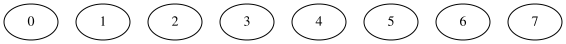

In [25]:
ds = Disjoinset(10)
ds.draw_ufds()

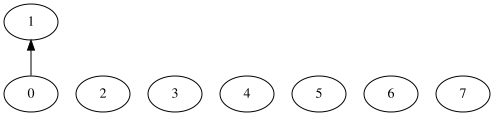

In [26]:
ds.union(0, 1)
ds.draw_ufds()